## Variables Aleatorias Continuas

### ¿Qué las hace diferentes?

| Característica | Discreta | Continua |
|----------------|----------|----------|
| **Valores** | Conjunto finito o numerable | Intervalo (infinitos valores) |
| **Ejemplo** | Número de caras al lanzar una moneda | Altura de una persona |
| **Probabilidad puntual** | $P(X=k) > 0$ | $P(X=a) = 0$ |
| **Función** | Función de masa (pmf) | Función de densidad (pdf) |
| **Suma/Integral** | $\sum P(X=x_i) = 1$ | $\int f(x) dx = 1$ |
| **Probabilidad** | $P(a \leq X \leq b) = \sum_{x=a}^{b} P(X=x)$ | $P(a \leq X \leq b) = \int_a^b f(x) dx$ |

### 🎯 Analogía

> **Discreta:** Es como contar canicas (solo números enteros: 1, 2, 3...)
>
> **Continua:** Es como medir la altura (puede ser 1.75, 1.751, 1.7512...)

### 📝 Función de Densidad (pdf)

La función de densidad $f(x)$ debe cumplir:

1. $f(x) \geq 0$ para todo $x$
2. $\int_{-\infty}^{\infty} f(x) dx = 1$
3. $P(a \leq X \leq b) = \int_a^b f(x) dx$

### 📝 Función de Distribución (CDF)

$$F(x) = P(X \leq x) = \int_{-\infty}^{x} f(t) dt$$

### 🔑 Relación clave

$$\frac{d}{dx}F(x) = f(x)$$

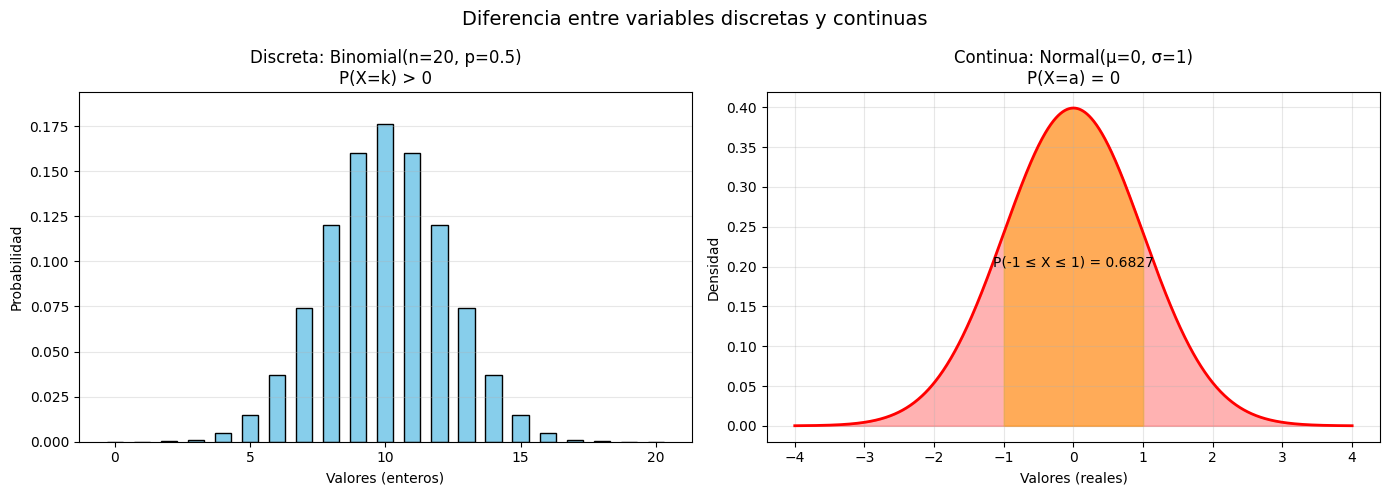

In [1]:
# Comparación Discreta vs Continua
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm
from ipywidgets import interact, widgets

def comparacion_discreta_continua():
    """
    Compara visualmente una distribución discreta (Binomial) 
    vs una continua (Normal)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribución Discreta: Binomial
    n, p = 20, 0.5
    x_disc = np.arange(0, n+1)
    pmf = binom.pmf(x_disc, n, p)
    
    ax1.bar(x_disc, pmf, width=0.6, color='skyblue', edgecolor='black')
    ax1.set_xlabel('Valores (enteros)')
    ax1.set_ylabel('Probabilidad')
    ax1.set_title('Discreta: Binomial(n=20, p=0.5)\nP(X=k) > 0')
    ax1.set_ylim(0, max(pmf)*1.1)
    ax1.grid(axis='y', alpha=0.3)
    
    # Distribución Continua: Normal
    x_cont = np.linspace(-4, 4, 1000)
    pdf = norm.pdf(x_cont, 0, 1)
    
    ax2.plot(x_cont, pdf, 'r-', linewidth=2)
    ax2.fill_between(x_cont, pdf, alpha=0.3, color='red')
    ax2.set_xlabel('Valores (reales)')
    ax2.set_ylabel('Densidad')
    ax2.set_title('Continua: Normal(μ=0, σ=1)\nP(X=a) = 0')
    ax2.grid(alpha=0.3)
    
    # Rellenar área para mostrar probabilidad
    x_fill = np.linspace(-1, 1, 100)
    ax2.fill_between(x_fill, norm.pdf(x_fill, 0, 1), 
                      alpha=0.5, color='orange')
    ax2.text(0, 0.2, f'P(-1 ≤ X ≤ 1) = {norm.cdf(1,0,1)-norm.cdf(-1,0,1):.4f}', 
             ha='center', fontsize=10)
    
    plt.suptitle('Diferencia entre variables discretas y continuas', fontsize=14)
    plt.tight_layout()
    plt.show()

comparacion_discreta_continua()